In [2]:
!python -V


Python 3.13.15


In [1]:

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")


Versión de TensorFlow: 2.20.0


In [3]:
!nvidia-smi

Fri Aug 28 19:33:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
print("versión de Keras:", tf.keras.__version__)

versión de Keras: 3.13.2


In [5]:
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import tensorflow as tf

print("GPUs disponibles:")
print(tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("GPU detectada correctamente")
else:
    print("No se detectó ninguna GPU")

GPUs disponibles:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detectada correctamente


In [7]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
class_names = ['Camiseta/top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                'Sandalia', 'Camisa', 'Zapatilla deportiva', 'Bolso', 'Botas/tacones']

In [8]:
train_images.shape

(60000, 28, 28)

In [9]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

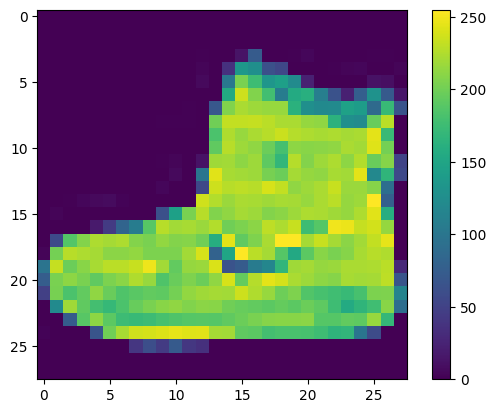

In [10]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

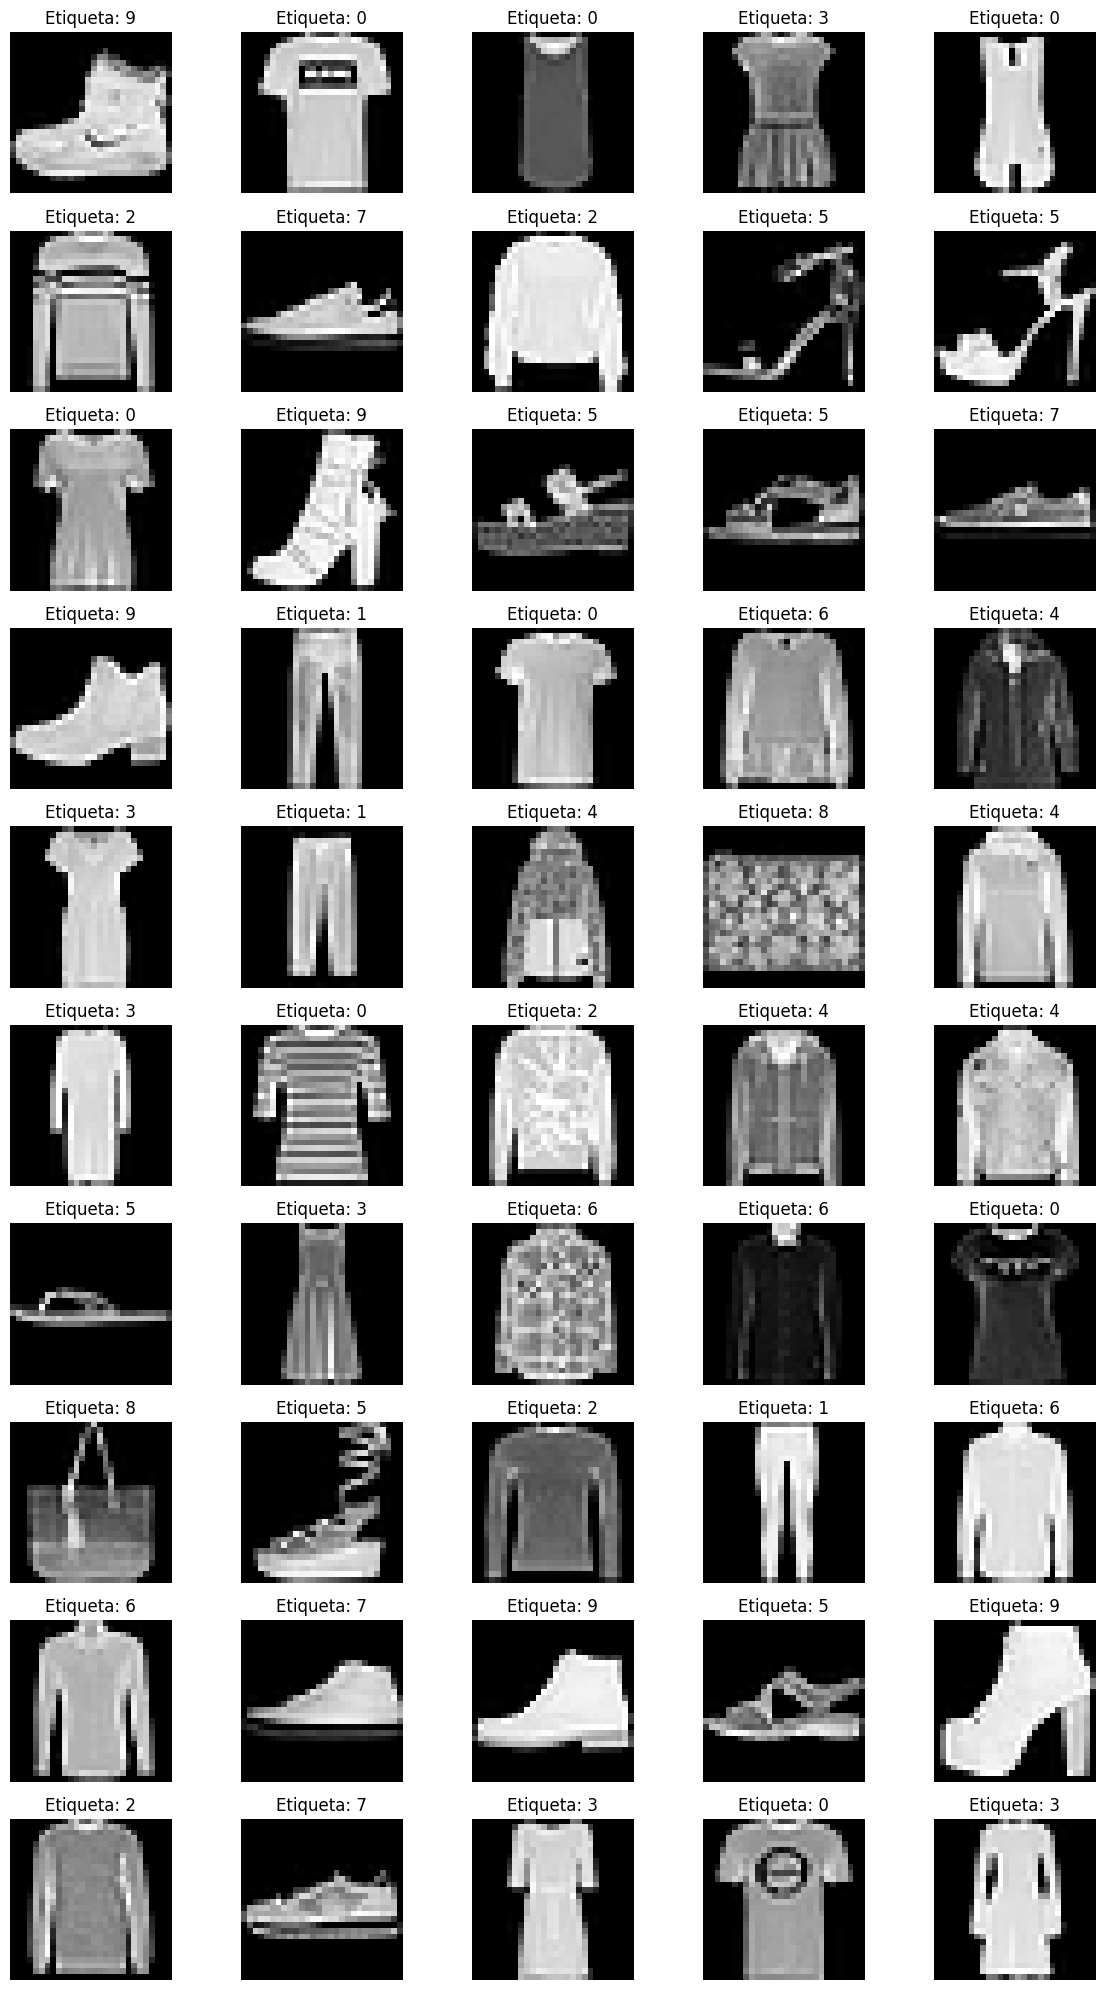

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 5, figsize=(12, 20))

for i, ax in enumerate(axes.flat):
    imagen = np.array(train_images[i]).squeeze()
    etiqueta = train_labels[i]

    if hasattr(etiqueta, "item"):
        etiqueta = etiqueta.item()

    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Etiqueta: {etiqueta}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [24]:
model = tf.keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [21]:
model_b = models.Sequential(name="Modelo_Add")

model_b.add(layers.Input(shape=(28, 28)))
model_b.add(layers.Flatten())
model_b.add(layers.Dense(64, activation="relu"))
model_b.add(layers.Dropout(0.2))
model_b.add(layers.Dense(32, activation="relu"))
model_b.add(layers.Dense(10, activation="softmax"))

In [25]:
model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
model_b.summary()


Model: "Modelo_Add"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
historial = model_b.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1002 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3028
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0988 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0996 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0969 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0981 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3029
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0970 - loss: 2.3028 - val_accuracy: 0.0983 - val_loss: 2.3028
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1003 - val_loss: 2.3026
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0973 - loss: 2.3028 - 

In [28]:
test_loss, test_accuracy = model_b.evaluate(test_images, test_labels)

print("Pérdida:", test_loss)
print("Precisión:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0816 - loss: 2.3132
Pérdida: 2.3131580352783203
Precisión: 0.08160000294446945


In [29]:
model_b.save("modelo_fashion_mnist.keras")
print("Modelo guardado correctamente")

Modelo guardado correctamente


In [30]:
!pwd

/content


In [31]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [32]:
ruta_modelo = "/content/drive/MyDrive/modelo_fashion_mnist.keras"

model_b.save(ruta_modelo)

print(f"Modelo guardado en: {ruta_modelo}")

Modelo guardado en: /content/drive/MyDrive/modelo_fashion_mnist.keras


In [33]:
import os

carpeta = "/content/drive/MyDrive/Redes densas"
os.makedirs(carpeta, exist_ok=True)

ruta_modelo = os.path.join(carpeta, "modelo_fashion_mnist.keras")
model_b.save(ruta_modelo)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [34]:
ruta_modelo = r"G:\Mi unidad\Redes densas\modelo_fashion_mnist.keras"

model_b.save(ruta_modelo)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [35]:
import os

print(os.path.exists(ruta_modelo))

True


In [37]:
predictions = model_b.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [38]:
predictions[0]

array([0.09251624, 0.08684446, 0.12152185, 0.07577813, 0.081282  ,
       0.10199597, 0.13748722, 0.1317951 , 0.0785736 , 0.09220538],
      dtype=float32)

In [39]:
posicion=np.argmax(predictions[0])

In [41]:
predicted_class = class_names[posicion]
print(f"Predicción de la primera imagen de prueba: {predicted_class}")

Predicción de la primera imagen de prueba: Camisa


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Seleccionar y subir la imagen de Paint
archivo = files.upload()
nombre_archivo = next(iter(archivo))

# Abrir, convertir a escala de grises y asegurar tamaño 28x28
imagen = Image.open(nombre_archivo).convert("L").resize((28, 28))

# Convertir a valores entre 0 y 1
imagen_array = np.array(imagen).astype("float32") / 255.0

# Fashion-MNIST usa fondo negro y objeto claro.
# Invierte la imagen si tiene fondo blanco.
if imagen_array.mean() > 0.5:
    imagen_array = 1.0 - imagen_array

# Mostrar la imagen procesada
plt.imshow(imagen_array, cmap="gray")
plt.axis("off")
plt.show()

# Preparar la imagen para el modelo
entrada = np.expand_dims(imagen_array, axis=0)

# Realizar predicción
predicciones = model_b.predict(entrada, verbose=0)
indice_prediccion = np.argmax(predicciones[0])
confianza = predicciones[0][indice_prediccion]

class_names = [
    "Camiseta/top",
    "Pantalón",
    "Suéter",
    "Vestido",
    "Abrigo",
    "Sandalia",
    "Camisa",
    "Zapatilla deportiva",
    "Bolso",
    "Botas/tacones"
]

print(f"Predicción: {class_names[indice_prediccion]}")
print(f"Confianza: {confianza:.2%}")